In [0]:
from pyspark.sql.functions import *

appointments_data = [
    (1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
    (1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
    (1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
    (1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
    (1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
    (1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
    (1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
    (1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
    (1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
    (1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
    (1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
    (1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
    (1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
    (1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
    (1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]

columns = [
    "appointment_id",
    "city",
    "department",
    "hospital",
    "consultation_fee",
    "status"
]

df = spark.createDataFrame(appointments_data, columns)

display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


+---------+-------+
|     city|revenue|
+---------+-------+
|Hyderabad|   5600|
|Bangalore|   6400|
|   Mumbai|   4800|
|    Delhi|   8000|
|  Chennai|   4550|
+---------+-------+



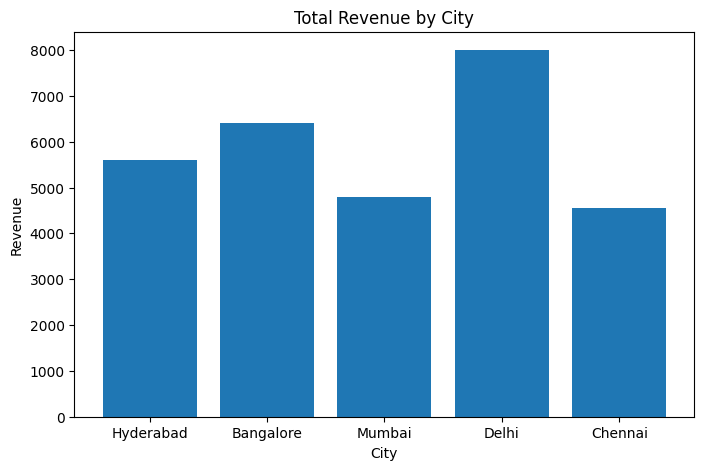

In [0]:
revenue_by_city = (
    df
    .groupBy("city")
    .agg(sum("consultation_fee").alias("revenue"))
)
revenue_by_city.show()

import matplotlib.pyplot as plt

city_pd = revenue_by_city.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd['city'], city_pd['revenue'])
plt.title("Total Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()



+-----------+-------+
| department|revenue|
+-----------+-------+
| Cardiology|  10500|
|  Neurology|   7500|
|Dermatology|   2850|
|Orthopedics|   4900|
| Pediatrics|   3600|
+-----------+-------+



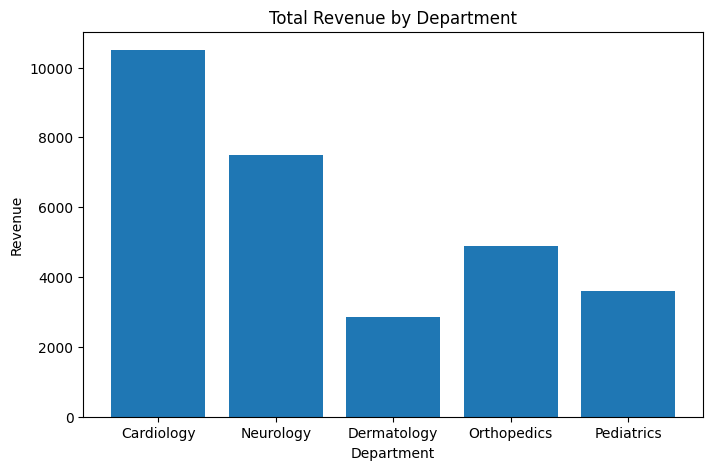

In [0]:
revenue_by_dept = df.groupBy('department').agg(sum('consultation_fee').alias('revenue'))

revenue_by_dept.show()

import matplotlib.pyplot as plt

dept_pd = revenue_by_dept.toPandas()

plt.figure(figsize=(8,5))
plt.bar(dept_pd['department'], dept_pd['revenue'])
plt.title("Total Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

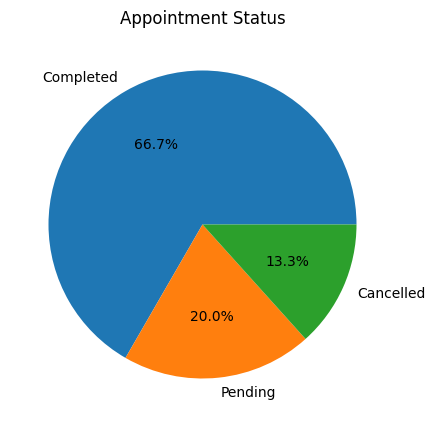

In [0]:
appointment_pd = df.select('status').toPandas()

plt.figure(figsize=(8,5))
plt.pie(
        appointment_pd['status'].value_counts(), 
        labels=appointment_pd['status'].value_counts().index, 
        autopct='%1.1f%%'
    )
plt.title("Appointment Status")
plt.show()

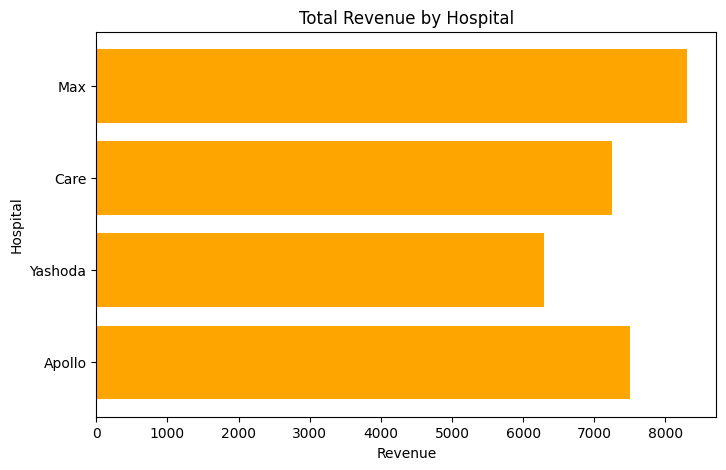

In [0]:
hosptial_rev = df.groupBy('hospital').agg(sum('consultation_fee').alias('revenue'))

hosp_pd = hosptial_rev.toPandas()
plt.figure(figsize=(8,5))
plt.barh(
    hosp_pd['hospital'], 
    hosp_pd['revenue'], 
    color='orange'
)
plt.title("Total Revenue by Hospital")
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.show()

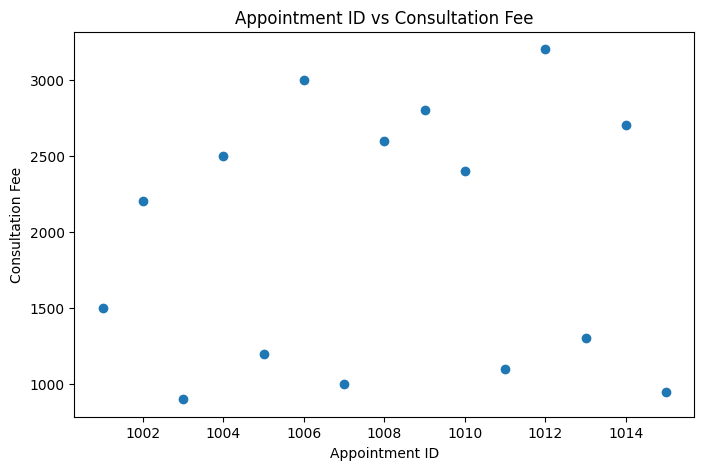

In [0]:
appoint_fee_pd = df.select('appointment_id', 'consultation_fee').toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    appoint_fee_pd['appointment_id'], 
    appoint_fee_pd['consultation_fee']
)
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

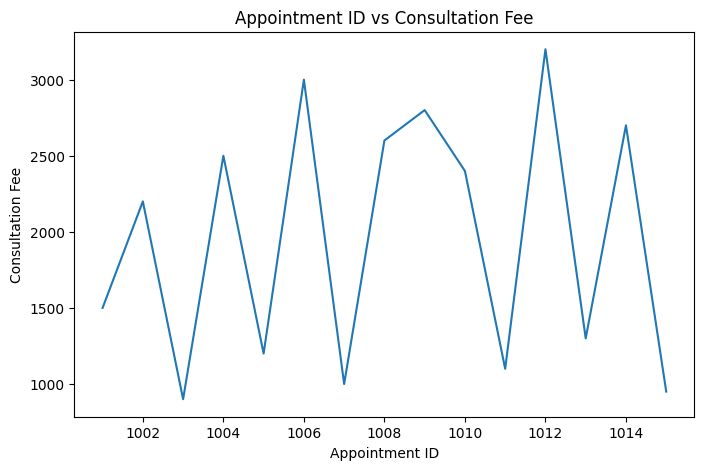

In [0]:
appoint_fee_pd = df.select('appointment_id', 'consultation_fee').toPandas()

plt.figure(figsize=(8,5))
plt.plot(
    appoint_fee_pd['appointment_id'], 
    appoint_fee_pd['consultation_fee']
)
plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

        city  count(appointment_id)
0  Hyderabad                      3
1  Bangalore                      3
2     Mumbai                      3
3      Delhi                      3
4    Chennai                      3


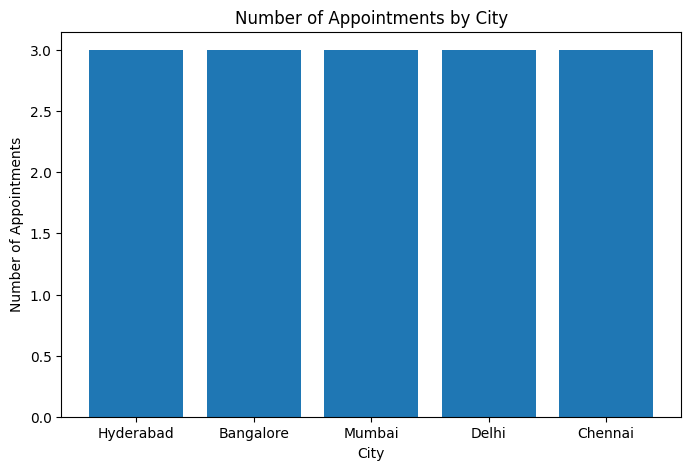

In [0]:
app_city_pd = df.groupBy('city').agg(count('appointment_id')).toPandas()
print(app_city_pd)
plt.figure(figsize=(8,5))
plt.bar(app_city_pd['city'], app_city_pd['count(appointment_id)'])
plt.title("Number of Appointments by City")
plt.xlabel("City")
plt.ylabel("Number of Appointments")
plt.show()

    department  count(appointment_id)
0   Cardiology                      4
1    Neurology                      3
2  Dermatology                      3
3  Orthopedics                      2
4   Pediatrics                      3


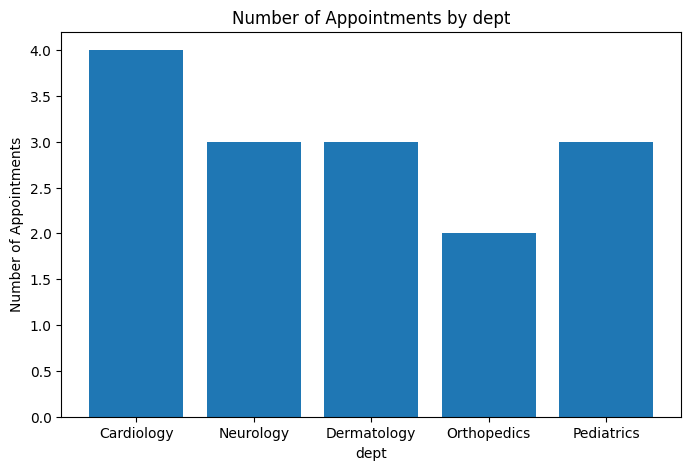

In [0]:
app_dept_pd = df.groupBy('department').agg(count('appointment_id')).toPandas()
print(app_dept_pd)
plt.figure(figsize=(8,5))
plt.bar(app_dept_pd['department'], app_dept_pd['count(appointment_id)'])
plt.title("Number of Appointments by dept")
plt.xlabel("dept")
plt.ylabel("Number of Appointments")
plt.show()

       status
0   Completed
1   Completed
2     Pending
3   Completed
4   Cancelled
5   Completed
6   Completed
7     Pending
8   Completed
9   Completed
10  Completed
11  Completed
12  Cancelled
13  Completed
14    Pending


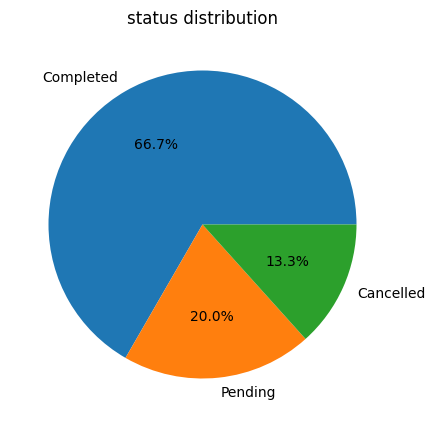

In [0]:
status_pd = df.select('status').toPandas()
print(status_pd)
plt.figure(figsize=(8,5))
plt.pie(
    status_pd['status'].value_counts().values,
    labels=status_pd['status'].value_counts().index,
    autopct='%1.1f%%'
)
plt.title('status distribution')
plt.show()

        city  sum(consultation_fee)
0  Hyderabad                   5600
1  Bangalore                   6400
2     Mumbai                   4800
3      Delhi                   8000
4    Chennai                   4550


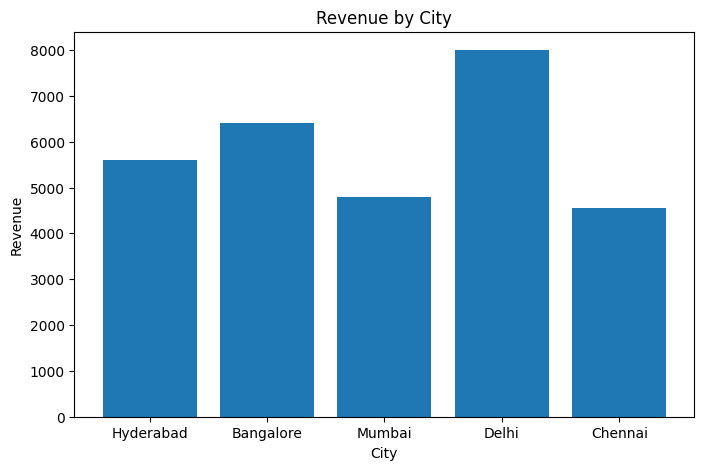

    department  sum(consultation_fee)
0   Cardiology                  10500
1    Neurology                   7500
2  Dermatology                   2850
3  Orthopedics                   4900
4   Pediatrics                   3600


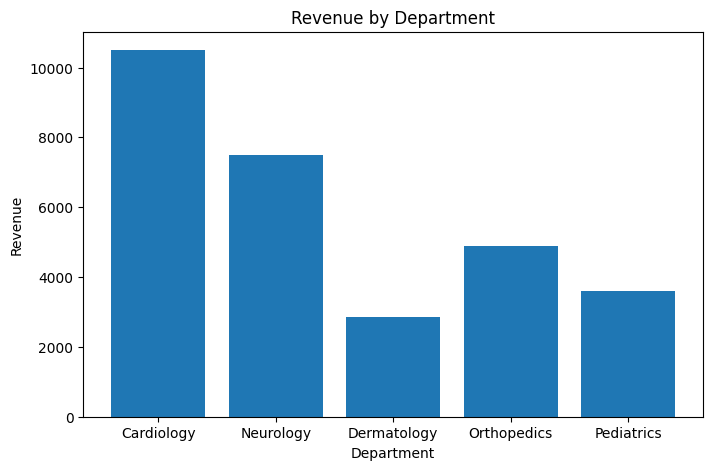

  hospital  sum(consultation_fee)
0   Apollo                   7500
1  Yashoda                   6300
2     Care                   7250
3      Max                   8300


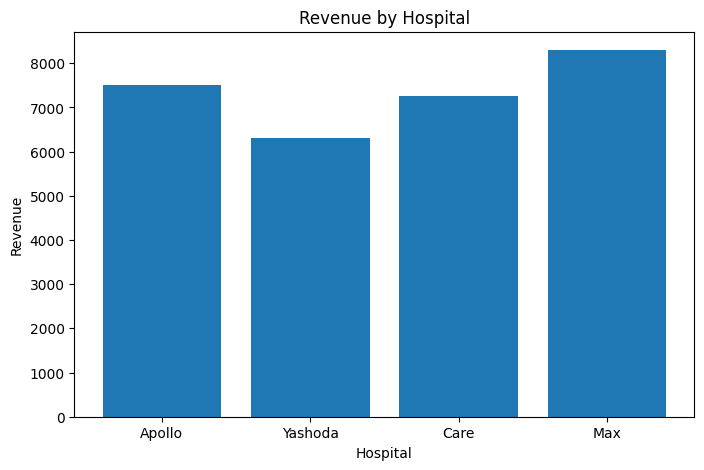

In [0]:
rev_city_pd = df.groupBy('city').agg(sum('consultation_fee')).toPandas()
print(rev_city_pd)
plt.figure(figsize=(8,5))
plt.bar(
    rev_city_pd['city'], 
    rev_city_pd['sum(consultation_fee)']
)
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

rev_dept_pd = df.groupBy('department').agg(sum('consultation_fee')).toPandas()
print(rev_dept_pd)
plt.figure(figsize=(8,5))
plt.bar(
    rev_dept_pd['department'], 
    rev_dept_pd['sum(consultation_fee)']
)
plt.title("Revenue by Department")
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.show()

rev_hosp_pd = df.groupBy('hospital').agg(sum('consultation_fee')).toPandas()
print(rev_hosp_pd)
plt.figure(figsize=(8,5))
plt.bar(
    rev_hosp_pd['hospital'], 
    rev_hosp_pd['sum(consultation_fee)']
)
plt.title("Revenue by Hospital")
plt.xlabel("Hospital")
plt.ylabel("Revenue")
plt.show()

    appointment_id  consultation_fee
0             1001              1500
1             1002              2200
2             1003               900
3             1004              2500
4             1005              1200
5             1006              3000
6             1007              1000
7             1008              2600
8             1009              2800
9             1010              2400
10            1011              1100
11            1012              3200
12            1013              1300
13            1014              2700
14            1015               950


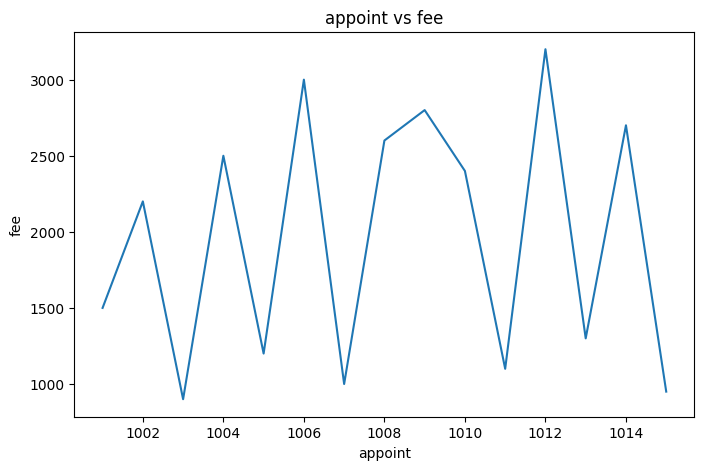

In [0]:
appoint_fee_pd = df.select('appointment_id', 'consultation_fee').toPandas()
print(appoint_fee_pd)
plt.figure(figsize=(8,5))
plt.plot(
    appoint_fee_pd['appointment_id'],
    appoint_fee_pd['consultation_fee']
)
plt.title('appoint vs fee')
plt.xlabel('appoint')
plt.ylabel('fee')
plt.show()

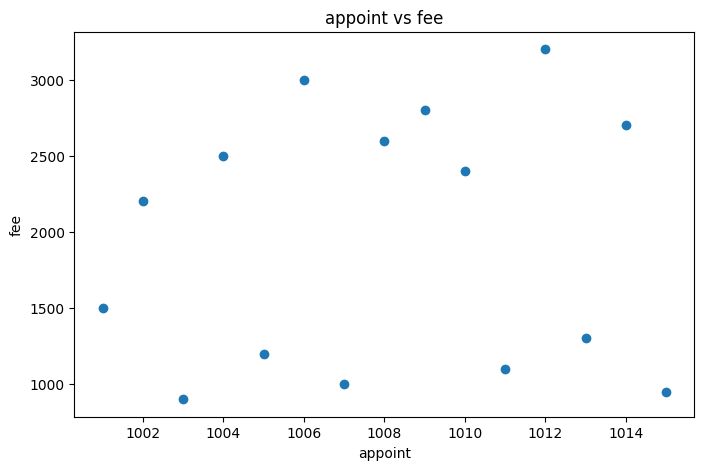

In [0]:
plt.figure(figsize=(8,5))
plt.scatter(
    appoint_fee_pd['appointment_id'],
    appoint_fee_pd['consultation_fee']
)
plt.title('appoint vs fee')
plt.xlabel('appoint')
plt.ylabel('fee')
plt.show()

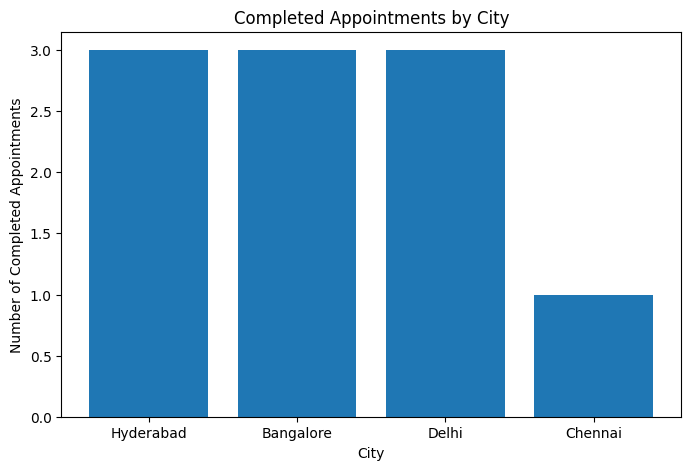

In [0]:
completed_df = df.filter(df.status == "Completed")
completed_city = (
    completed_df
    .groupBy("city")
    .agg(count("*").alias("completed_count"))
)
completed_pd = completed_city.toPandas()
plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["city"],
    completed_pd["completed_count"]
)
plt.title("Completed Appointments by City")
plt.xlabel("City")
plt.ylabel("Number of Completed Appointments")
plt.show()

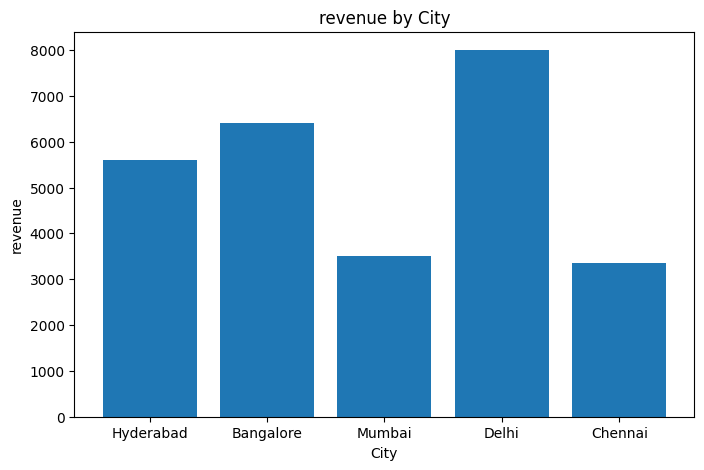

In [0]:
completed_df = df.filter(df.status != "Cancelled")
completed_city = (
    completed_df
    .groupBy("city")
    .agg(sum('consultation_fee').alias("revenue"))
)
completed_pd = completed_city.toPandas()
plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["city"],
    completed_pd["revenue"]
)
plt.title("revenue by City")
plt.xlabel("City")
plt.ylabel("revenue")
plt.show()

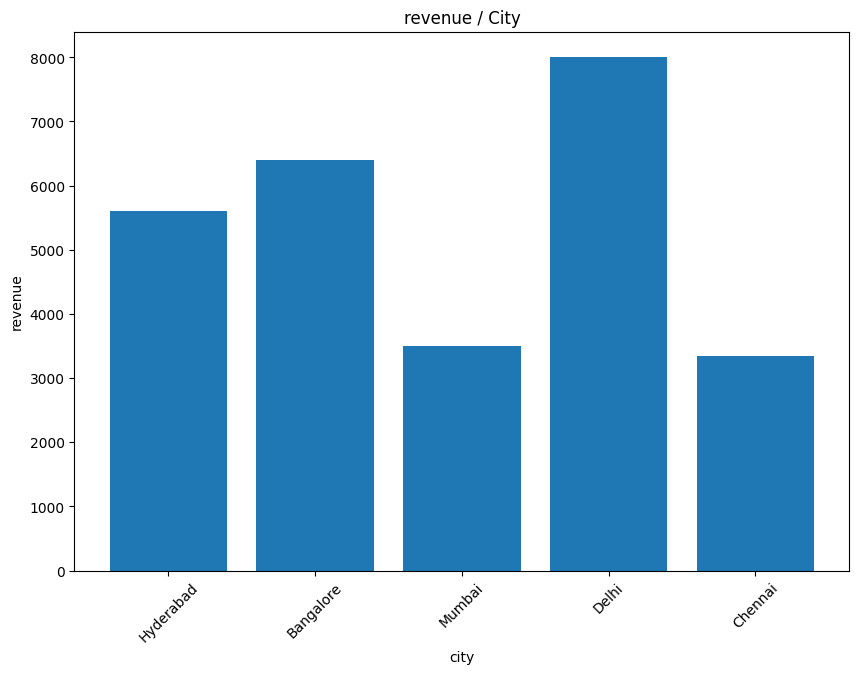

In [0]:
plt.figure(figsize=(10,7))
plt.bar(
    completed_pd["city"],
    completed_pd["revenue"]
)
plt.title("revenue / City")
plt.xlabel("city")
plt.ylabel("revenue")
plt.xticks(rotation=45)
plt.show()

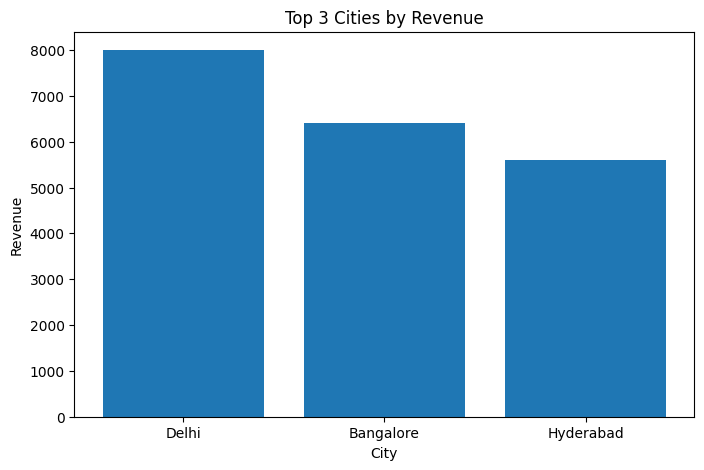

In [0]:
completed_df = df.filter(df.status != "Cancelled")

completed_city = (
    completed_df
    .groupBy("city")
    .agg(sum("consultation_fee").alias("revenue"))
    .orderBy(col("revenue").desc())
    .limit(3)
)

completed_pd = completed_city.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["city"],
    completed_pd["revenue"]
)

plt.title("Top 3 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.show()

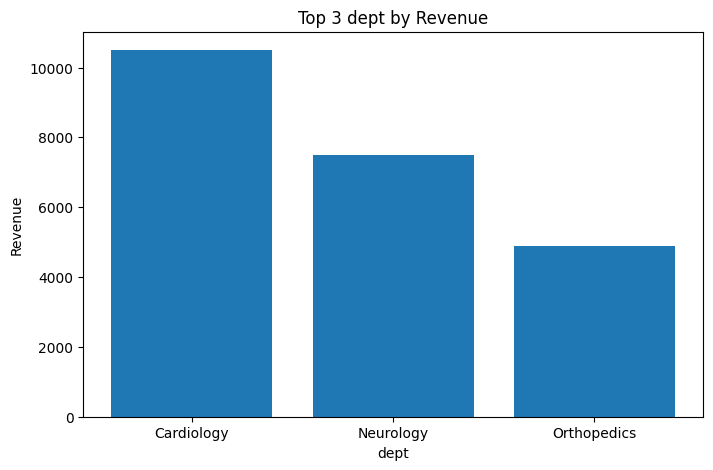

In [0]:
completed_df = df.filter(df.status != "Cancelled")

completed_dept = (
    completed_df
    .groupBy("department")
    .agg(sum("consultation_fee").alias("revenue"))
    .orderBy(col("revenue").desc())
    .limit(3)
)

completed_pd = completed_dept.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["department"],
    completed_pd["revenue"]
)

plt.title("Top 3 dept by Revenue")
plt.xlabel("dept")
plt.ylabel("Revenue")
plt.show()

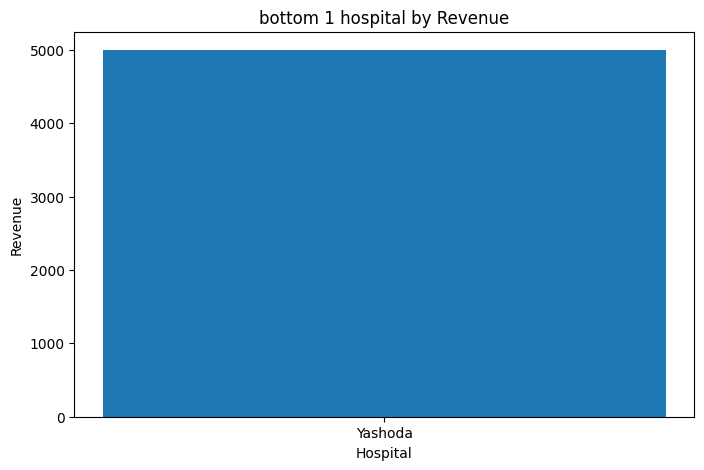

In [0]:
completed_df = df.filter(df.status != "Cancelled")

completed_hosp = (
    completed_df
    .groupBy("hospital")
    .agg(sum("consultation_fee").alias("revenue"))
    .orderBy(col("revenue"))
    .limit(1)
)

completed_pd = completed_hosp.toPandas()

plt.figure(figsize=(8,5))
plt.bar(
    completed_pd["hospital"],
    completed_pd["revenue"]
)

plt.title("bottom 1 hospital by Revenue")
plt.xlabel("Hospital")
plt.ylabel("Revenue")
plt.show()

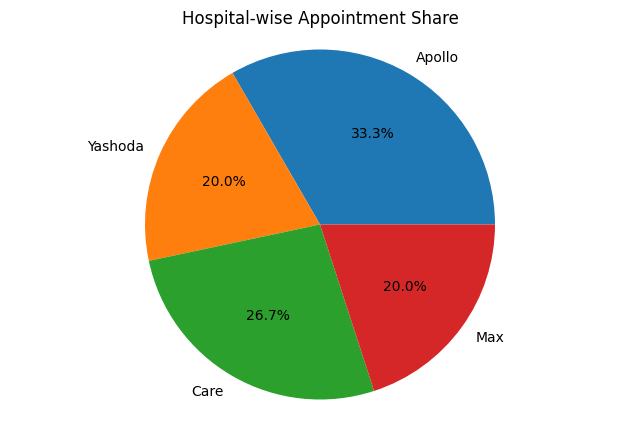

In [0]:
appoint_df = (
    df.groupBy("hospital")
      .agg(count("appointment_id").alias("appoint_count"))
)

appoint_pd = appoint_df.toPandas()

plt.figure(figsize=(8,5))

plt.pie(
    appoint_pd["appoint_count"],
    labels=appoint_pd["hospital"],
    autopct="%1.1f%%"
)

plt.title("Hospital-wise Appointment Share")
plt.axis("equal")  # Makes the pie chart circular
plt.show()

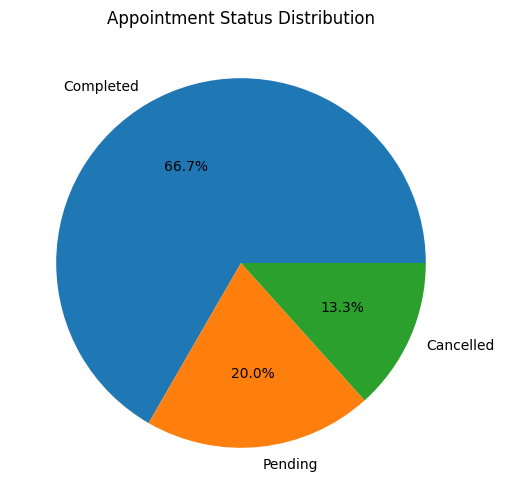

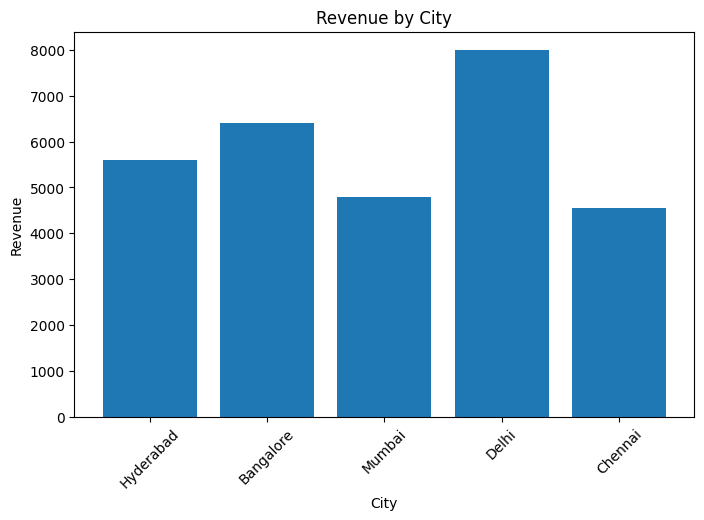

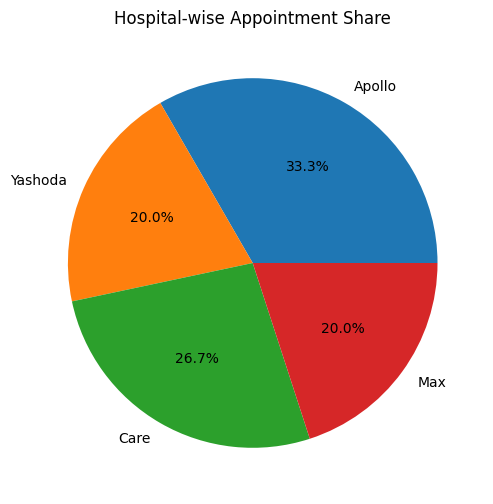

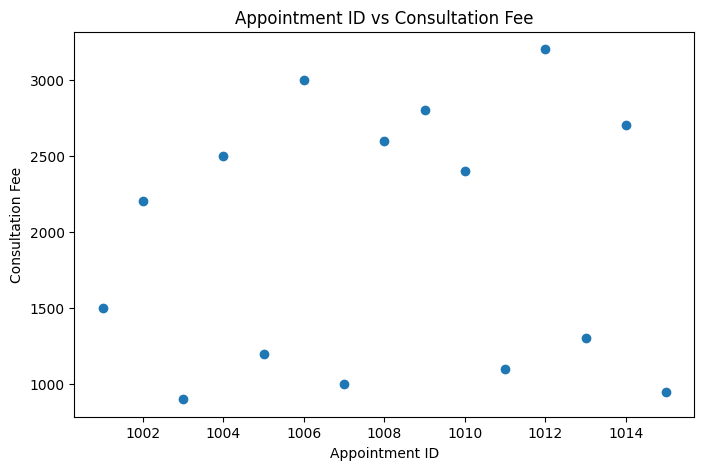

In [0]:
status_pd = df.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

city_pd = (
    df.groupBy("city")
      .agg(sum("consultation_fee").alias("revenue"))
      .toPandas()
)

plt.figure(figsize=(8,5))
plt.bar(city_pd["city"], city_pd["revenue"])
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

hospital_pd = (
    df.groupBy("hospital")
      .agg(count("appointment_id").alias("appointments"))
      .toPandas()
)

plt.figure(figsize=(6,6))
plt.pie(
    hospital_pd["appointments"],
    labels=hospital_pd["hospital"],
    autopct="%1.1f%%"
)
plt.title("Hospital-wise Appointment Share")
plt.show()

scatter_pd = df.select(
    "appointment_id",
    "consultation_fee"
).toPandas()

plt.figure(figsize=(8,5))
plt.scatter(
    scatter_pd["appointment_id"],
    scatter_pd["consultation_fee"]
)

plt.title("Appointment ID vs Consultation Fee")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.show()

In [0]:
city_df = (
    df.groupBy("city")
      .agg(count("*").alias("appointment_count"))
)

city_pd = city_df.toPandas()

Chart_Type = "Bar"
X_Axis = city_pd["city"]
Y_Axis = city_pd["appointment_count"]
Title = "Appointment Count by City"